<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8012/blob/main/laboratorio_calificado_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejercicio 1: Clasificador usando Regresión Logística

### Descripción

Entrenar un modelo de regresión logística para clasificar imágenes entre 3 tipos de
clases. Para ello escoja 3 clases entre las 10 que ofrece el dataset de CIFAR-10.

In [10]:
# Importar librerias de Python

import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

### Tarea 1 - Carga de Datos y Selección de Clases

Cargar del dataset CIFAR-10 y extraer solo 3 clases para el entrenamiento (use
cifar10.load_data() y use los valores por defecto que devuelve)

In [2]:
# Cargar el dataset CIFAR-10
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
print(f'Dataset Completo')
print(f' - Tamaño de X_train: {X_train_full.shape}')
print(f' - Tamaño de X_test: {X_test_full.shape}')
print(f' - Tamaño de y_train: {y_train_full.shape}')
print(f' - Tamaño de y_test: {y_test_full.shape}')

# Nombres originales de las clases en CIFAR-10 para referencia
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Clases seleccionadas: 0 (airplane), 1 (automobile), 8 (ship)
class1_id = 0
class2_id = 1
class3_id = 8
selected_classes = [class1_id, class2_id, class3_id]
class_mapping = {original: new for new, original in enumerate(selected_classes)}

# Aplanar las etiquetas
y_train_flatten = y_train_full.flatten()
y_test_flatten = y_test_full.flatten()

# Crear máscaras para filtrar los datos con las etiquetas full aplanadas
train_mask = np.isin(y_train_flatten, selected_classes)
test_mask = np.isin(y_test_flatten, selected_classes)

# Filtrar los datos
X_train_filtered = X_train_full[train_mask]
y_train_filtered = y_train_flatten[train_mask]
X_test_filtered = X_test_full[test_mask]
y_test_filtered = y_test_flatten[test_mask]

# Re-mapeo de etiquetas para las clases seleccionadas
y_train_remapped = np.array([class_mapping[label] for label in y_train_filtered])
y_test_remapped = np.array([class_mapping[label] for label in y_test_filtered])

# Mostrar tamaños
print('\n')
print(f'Dataset Filtrado y Re-mapeado')
print(f' - Tamaño de X_train_filtered: {X_train_filtered.shape}')
print(f' - Tamaño de X_test_filtered: {X_test_filtered.shape}')
print(f' - Tamaño de y_train_remapped: {y_train_remapped.shape}')
print(f' - Tamaño de y_test_remapped: {y_test_remapped.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Dataset Completo
 - Tamaño de X_train: (50000, 32, 32, 3)
 - Tamaño de X_test: (10000, 32, 32, 3)
 - Tamaño de y_train: (50000, 1)
 - Tamaño de y_test: (10000, 1)


Dataset Filtrado y Re-mapeado
 - Tamaño de X_train_filtered: (15000, 32, 32, 3)
 - Tamaño de X_test_filtered: (3000, 32, 32, 3)
 - Tamaño de y_train_remapped: (15000,)
 - Tamaño de y_test_remapped: (3000,)


### Tarea 2 - Función de Extracción de Características

Crear una función que extraiga 8 características de cada imagen (en este caso
usaremos los canales R,G,B,H,S,V, bordes horizontales de sobel y bordes
verticales de sobel )

In [3]:
def extract_image_features(image: np.ndarray, sobel_ksize: int = 3):
    """
    Extrae un vector de características basado en 8 fuentes:
    Canales: R, G, B, H, S, V y Bordes Sobel (Horizontal y Vertical).
    Para maximizar la precisión, se extrae la media y la desviación estándar de cada uno.
    """
    # 1. Canales RGB (OpenCV carga por defecto en RGB desde el dataset de Keras)
    R_channel = image[:, :, 0]
    G_channel = image[:, :, 1]
    B_channel = image[:, :, 2]

    # 2. Conversión a HSV y extracción de canales
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    H_channel = hsv_image[:, :, 0]
    S_channel = hsv_image[:, :, 1]
    V_channel = hsv_image[:, :, 2]

    # 3. Conversión a escala de grises para detección de bordes
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # 4. Bordes de Sobel (convertidos a valor absoluto y uint8)
    sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=sobel_ksize)
    sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=sobel_ksize)

    sobel_x_abs = np.absolute(sobel_x)
    sobel_y_abs = np.absolute(sobel_y)

    # Lista con las 8 fuentes de información solicitadas
    feature_maps = [
        R_channel, G_channel, B_channel,
        H_channel, S_channel, V_channel,
        sobel_x_abs, sobel_y_abs
    ]

    # Para capturar mejor la información sin perder la noción espacial (esencial para > 0.6),
    # calculamos la media y la desviación estándar de cada mapa.
    # Esto genera 8 * 2 = 16 características por imagen.
    # feature_vector = []
    # for f_map in feature_maps:
    #     feature_vector.append(np.mean(f_map))
    #     feature_vector.append(np.std(f_map))

    # Return the feature maps as a flattened 1D array
    return np.array(feature_maps).flatten()

### Tarea 3 - Entrenamiento y Evaluación

Usar las características extraídas para entrenar el modelo de regresión
logística, generar e imprimir un reporte de clasificación y una matriz de
confusió

In [4]:
# Funciones para preparar matriz de características, entrenar modelo y evaluar modelo

def prepare_feature_matrix(images: np.ndarray, sobel_ksize: int = 3, max_samples: int = None) -> np.ndarray:
    """Convierte un conjunto de imágenes a una matriz de características.

    Args:
        images (np.ndarray): arreglo de imágenes de tamaño (N, 32, 32, 3).
        sobel_ksize (int): tamaño del filtro de Sobel.
        max_samples (int, opcional): si se especifica, limita el número de muestras para acelerar el procesamiento.

    Returns:
        np.ndarray: matriz de características de tamaño (N, 8192).
    """
    if max_samples is not None:
        images = images[:max_samples]

    n_samples = images.shape[0]
    # Prealocar matriz de características
    features = np.zeros((n_samples, 32 * 32 * 8), dtype=np.float32)

    for i in range(n_samples):
        features[i, :] = extract_image_features(images[i], sobel_ksize=sobel_ksize)
    return features


def train_logistic_regression(X_train: np.ndarray, y_train: np.ndarray, max_iter: int = 200) -> LogisticRegression:
    """Entrena un modelo de regresión logística."""
    clf = LogisticRegression(max_iter=max_iter, solver='lbfgs')
    clf.fit(X_train, y_train)
    return clf


def evaluate_model(clf: LogisticRegression, X_test: np.ndarray, y_test: np.ndarray):
    """Evalúa el modelo y devuelve el reporte de clasificación y la matriz de confusión."""
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return report, cm


In [5]:
# Definir maxima cantidad de registros de entrenamiento y prueba
max_train = 8000  # cambia a None para usar todas las muestras
max_test = 2000

# Extraer características para entrenamiento y prueba
print("\nExtrayendo características del dataset...")
X_train_features = prepare_feature_matrix(X_train_filtered, sobel_ksize=3, max_samples=max_train)
X_test_features = prepare_feature_matrix(X_test_filtered, sobel_ksize=3, max_samples=max_test)

# Estandarización de características (para Regresión Logística)
scaler = StandardScaler()
X_train_feat_scaled = scaler.fit_transform(X_train_features)
X_test_feat_scaled = scaler.transform(X_test_features)

# Etiquetas correspondientes a caracteristicas seleccionadas
y_train_sub = y_train_remapped[:max_train] if max_train is not None else y_train_remapped
y_test_sub = y_test_remapped[:max_test] if max_test is not None else y_test_remapped


Extrayendo características del dataset...


In [6]:
# Entrenar modelo

print("\nEntrenando el modelo ...")
clf = train_logistic_regression(X_train_feat_scaled, y_train_sub, max_iter=2000)


Entrenando el modelo ...


In [7]:
# Evaluar modelo

print("\nEvaluando el modelo ...")
report, conf_matrix = evaluate_model(clf, X_test_feat_scaled, y_test_sub)
print("\nReporte de clasificación:\n", report)
print("\nMatriz de confusión:\n", conf_matrix)


Evaluando el modelo ...

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.68      0.69      0.68       678
           1       0.82      0.80      0.81       662
           2       0.68      0.70      0.69       660

    accuracy                           0.73      2000
   macro avg       0.73      0.73      0.73      2000
weighted avg       0.73      0.73      0.73      2000


Matriz de confusión:
 [[465  58 155]
 [ 74 527  61]
 [142  59 459]]



Visualizando la matriz de confusión ...


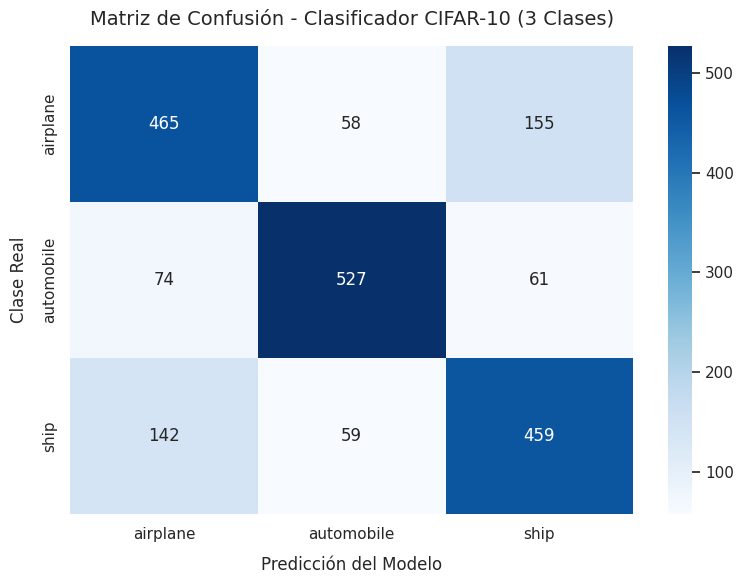

In [8]:
# Visualizar matriz de confusión

# Nombres de las clases mapeadas para el reporte gráfico
target_names = [cifar10_classes[sel_class] for sel_class in selected_classes]

# Generar gráfico de Matriz de Confusión
print("\nVisualizando la matriz de confusión ...")
plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Matriz de Confusión - Clasificador CIFAR-10 (3 Clases)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Clase Real', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### Tarea 4 - Variación de Hiperparámetros

Buscar una precisión mayor a 0.6 y variar hiperparámetros con la finalidad de
mejorar la precisión

In [9]:
def train_logistic_regression_hyper(X_train: np.ndarray, y_train: np.ndarray, max_iter: int = 200) -> LogisticRegression:
    """Entrena un modelo de regresión logística."""

    clf = LogisticRegression(
        C=5.0,
        solver='saga',
        multi_class='multinomial',
        max_iter=1500,
        random_state=42
    )

    clf.fit(X_train, y_train)
    return clf


In [ ]:
# Entrenar modelo


# Iniciar medición
start_time = time.time()

# Ejecutar la función
print("\nEntrenando el modelo ...")
clf = train_logistic_regression_hyper(X_train_feat_scaled, y_train_sub, max_iter=2000)

# Finalizar medición
finish_time = time.time()

print(f"Tiempo de ejecución de entrenamiento de modleo: {finish_time - start_time:.4f} segundos")


Entrenando el modelo ...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Evaluar modelo

print("\nEvaluando el modelo ...")
report, conf_matrix = evaluate_model(clf, X_test_feat_scaled, y_test_sub)
print("\nReporte de clasificación:\n", report)
print("\nMatriz de confusión:\n", conf_matrix)

In [ ]:
# Visualizar matriz de confusión

# Nombres de las clases mapeadas para el reporte gráfico
target_names = [cifar10_classes[sel_class] for sel_class in selected_classes]

# Generar gráfico de Matriz de Confusión
print("\nVisualizando la matriz de confusión ...")
plt.figure(figsize=(8, 6))
sns.set_theme(style='whitegrid')
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Matriz de Confusión - Clasificador CIFAR-10 (3 Clases)', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Clase Real', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()